# 07 Training a CNN on Image Datasets (CIFAR-10)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load **CIFAR-10**, preprocess it, and inspect shape and labels
- Build a small **CNN**, train it for a few epochs, and plot **loss/accuracy**
- Evaluate on the test set and see sample predictions

---

## 🌍 Real life

**Where is this used?** Training CNNs on image datasets is used in **product recognition**, **quality inspection**, and **medical image classification**.

**In this notebook we use** a **CNN** to **classify CIFAR-10** (32×32 color images, 10 classes). We use **CIFAR-10** (instead of ImageNet for this demo) **because** it is small and fast to train so you see the full pipeline in ~10 min.

**📌 Covers slide(s):** **11** — Image Segmentation / image pipelines (see README). *Do this notebook after core transfer-learning notebooks (05, 06).*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **CIFAR-10:** 50k train + 10k test, 32×32 RGB, 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).
- **Pipeline:** Load data → normalize → build CNN (Conv2D, MaxPool, Dense) → compile → train → evaluate.
- **We use a CNN** (instead of MLP on flattened pixels) because images have **spatial structure**; conv layers preserve it.
- **We use a small subset or few epochs** here so the notebook runs in ~10 min; in real projects you'd train longer.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. CIFAR-10 (built-in). We use a subset or 3 epochs so it runs quickly.

**Dataset:** Real — CIFAR-10 (natural images, 10 classes).

**Outputs:** Training/validation loss and accuracy curves (with axis labels), test accuracy, and a few sample predictions (true → predicted).

## Step 1: Imports and load CIFAR-10

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    y_train, y_test = y_train.flatten(), y_test.flatten()
    print("Train:", x_train.shape, "Test:", x_test.shape)
    print("Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)")
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)
Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)


## Step 2: Build CNN (we use Conv2D + MaxPool for spatial structure instead of flattening first)

In [2]:
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (3 epochs so it runs in ~5–10 min)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_split=0.1, epochs=3, batch_size=128, verbose=1)

Epoch 1/3


  1/352 ━━━━━━━━━━━━━━━━━━━━ 1:52 321ms/step - accuracy: 0.1250 - loss: 2.2867

  5/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1375 - loss: 2.3024   

 10/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1484 - loss: 2.2959

 15/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1542 - loss: 2.2856

...

338/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5901 - loss: 1.1748

342/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5905 - loss: 1.1745

347/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5905 - loss: 1.1737

352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5906 - loss: 1.1736

352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5906 - loss: 1.1736 - val_accuracy: 0.6098 - val_loss: 1.1223


## Step 4: Plot loss and accuracy

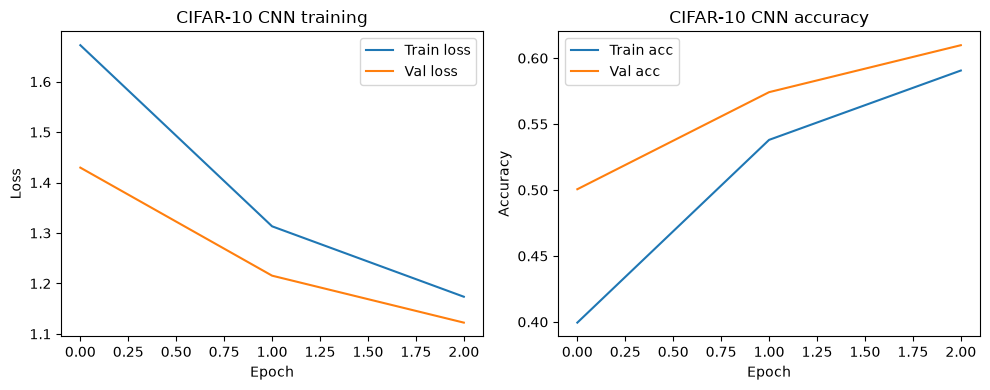

In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("CIFAR-10 CNN training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("CIFAR-10 CNN accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()

## Step 5: Evaluate and sample predictions

In [5]:
if HAS_TF:
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % test_acc)
    preds = np.argmax(model.predict(x_test[:5]), axis=1)
    print("Sample (true → predicted):", list(zip(y_test[:5].tolist(), preds.tolist())))

Test accuracy: 0.5971
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Sample (true → predicted): [(3, 3), (8, 8), (8, 8), (0, 0), (6, 6)]


## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

Epoch 1/10 — loss: 1.926


Epoch 2/10 — loss: 1.551


Epoch 3/10 — loss: 1.372


Epoch 4/10 — loss: 1.251


Epoch 5/10 — loss: 1.160


Epoch 6/10 — loss: 1.069


Epoch 7/10 — loss: 0.960


Epoch 8/10 — loss: 0.856


Epoch 9/10 — loss: 0.747


Epoch 10/10 — loss: 0.642

Test accuracy: 58.8%  (industry models reach 99%+ with bigger architectures)


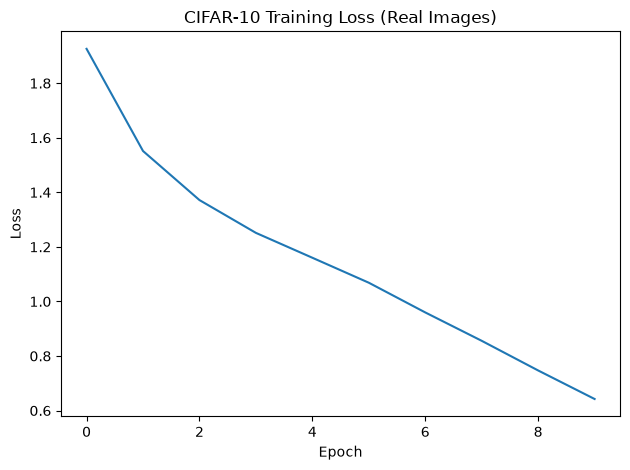

In [6]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

plt.plot(losses); plt.title("CIFAR-10 Training Loss (Real Images)"); plt.xlabel("Epoch")
plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it (choose one):** Add simple data augmentation (e.g. random flip or small rotation) before training and run for 2 epochs. Does test accuracy change? Or increase epochs to 5 and see if the model starts to overfit.

---

## ✅ Summary

**What you did:** Loaded CIFAR-10, built a CNN, trained for 3 epochs, plotted loss/accuracy, and evaluated with sample predictions.

**In real life you'd also:** Use data augmentation, more epochs, learning rate scheduling, and early stopping.

**The main idea:** Training a CNN on an image dataset follows: load → preprocess → build CNN → train → evaluate; we use conv layers to exploit spatial structure.

**Next:** `04_transfer_learning_object_detection` extends transfer learning to object detection; `01_cnn_architecture` introduces CNN layers.

## 📚 References & Further Reading

**Key Papers:**
- LeCun et al. (1998) — [LeNet](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf)
- Krizhevsky et al. (2012) — [AlexNet](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)
- He et al. (2016) — [ResNet: Deep Residual Learning](https://arxiv.org/abs/1512.03385)

**torchvision Models:** [torchvision.models](https://pytorch.org/vision/stable/models.html)

**State-of-the-Art (2025):** EfficientNetV2, ConvNeXt V2, and ViT-G/14 achieve 90%+ on ImageNet.